## Import the libraries

In [133]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR

from xgboost import XGBClassifier, XGBRegressor

import optuna

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Lassa Fever Dataset

In [54]:
df = pd.read_csv("Lassa_Fever/lassa_fever.csv")

df.head()

,week_start_date,week_end_date,epi_year,epi_week,suspected_cases,confirmed_cases,deaths,Unnamed: 7
0,2019-12-30,2020-01-05,2020,1,98,18,2,NaN
1,2020-01-06,2020-01-12,2020,2,158,64,12,NaN
2,2020-01-13,2020-01-19,2020,3,159,81,10,NaN
3,2020-01-20,2020-01-26,2020,4,318,95,19,NaN
4,2020-01-27,2020-02-02,2020,5,531,104,6,NaN


## DATASET OVERVIEW

In [55]:
print("="*60)
print("DATASET SHAPE")
print("="*60)

print(df.shape)

print()

print("="*60)
print("COLUMN NAMES")
print("="*60)

print(df.columns.tolist())

print()

print("="*60)
print("DATA TYPES")
print("="*60)

print(df.dtypes)

print()

print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

DATASET SHAPE
(313, 8)

COLUMN NAMES
['week_start_date', 'week_end_date', 'epi_year', 'epi_week', 'suspected_cases', 'confirmed_cases', 'deaths', 'Unnamed: 7']

DATA TYPES
week_start_date     object
week_end_date       object
epi_year             int64
epi_week             int64
suspected_cases      int64
confirmed_cases      int64
deaths               int64
Unnamed: 7         float64
dtype: object

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   week_start_date  313 non-null    object 
 1   week_end_date    313 non-null    object 
 2   epi_year         313 non-null    int64  
 3   epi_week         313 non-null    int64  
 4   suspected_cases  313 non-null    int64  
 5   confirmed_cases  313 non-null    int64  
 6   deaths           313 non-null    int64  
 7   Unnamed: 7       6 non-null      float64
dtypes: float

## Data Quality Assessment

In [56]:
print("="*60)
print("MISSING VALUES")
print("="*60)

print(df.isnull().sum())

print()

print("="*60)
print("DUPLICATE RECORDS")
print("="*60)

print(df.duplicated().sum())

MISSING VALUES
week_start_date      0
week_end_date        0
epi_year             0
epi_week             0
suspected_cases      0
confirmed_cases      0
deaths               0
Unnamed: 7         307
dtype: int64

DUPLICATE RECORDS
0


## Remove the Empty Column

In [57]:
# REMOVE EMPTY COLUMN
df = df.drop(columns=["Unnamed: 7"])

print(df.columns)

Index(['week_start_date', 'week_end_date', 'epi_year', 'epi_week', 'suspected_cases', 'confirmed_cases', 'deaths'], dtype='object')


## Convert Dates

In [58]:
# CONVERT DATE VARIABLES
df["week_start_date"] = pd.to_datetime(df["week_start_date"])

df["week_end_date"] = pd.to_datetime(df["week_end_date"])

df.dtypes

week_start_date    datetime64[ns]
week_end_date      datetime64[ns]
epi_year                    int64
epi_week                    int64
suspected_cases             int64
confirmed_cases             int64
deaths                      int64
dtype: object

## Descriptive Statistics

In [59]:
# DESCRIPTIVE STATISTICS
df.describe().T

,count,mean,min,25%,50%,75%,max,std
week_start_date,313,2022-12-26 00:00:00,2019-12-30 00:00:00,2021-06-28 00:00:00,2022-12-26 00:00:00,2024-06-24 00:00:00,2025-12-22 00:00:00,NaN
week_end_date,313,2023-01-01 00:00:00,2020-01-05 00:00:00,2021-07-04 00:00:00,2023-01-01 00:00:00,2024-06-30 00:00:00,2025-12-28 00:00:00,NaN
epi_year,313.0,2022.492013,2020.0,2021.0,2022.0,2024.0,2025.0,1.713661
epi_week,313.0,26.584665,1.0,14.0,27.0,40.0,53.0,15.082891
suspected_cases,313.0,152.760383,11.0,81.0,115.0,180.0,694.0,111.765939
confirmed_cases,313.0,20.626198,0.0,6.0,10.0,22.0,137.0,25.664706
deaths,313.0,3.127796,0.0,0.0,1.0,3.0,23.0,4.544258


## Exploratory Data Analysis (EDA)

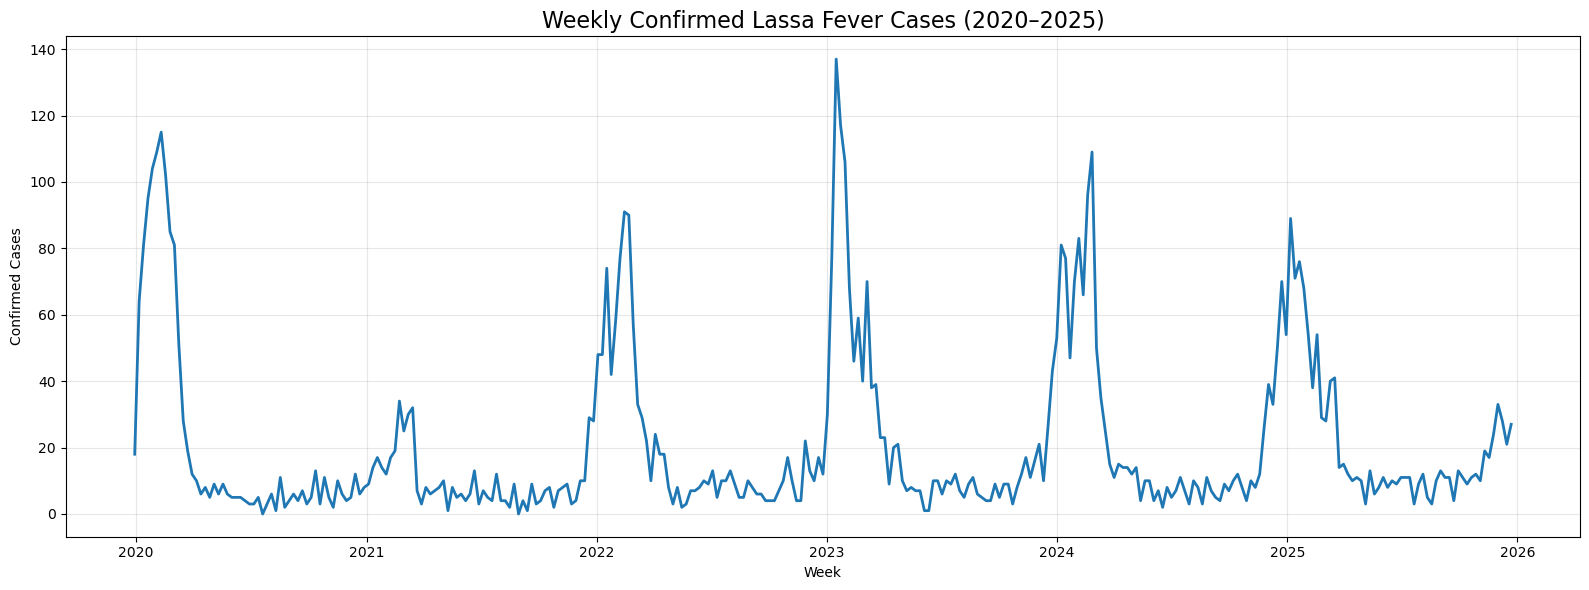

In [60]:
# WEEKLY CONFIRMED CASES

plt.figure(figsize=(16,6))

plt.plot(
    df["week_start_date"],
    df["confirmed_cases"],
    linewidth=2
)

plt.title("Weekly Confirmed Lassa Fever Cases (2020–2025)", fontsize=16)

plt.xlabel("Week")

plt.ylabel("Confirmed Cases")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Weekly Suspected Cases

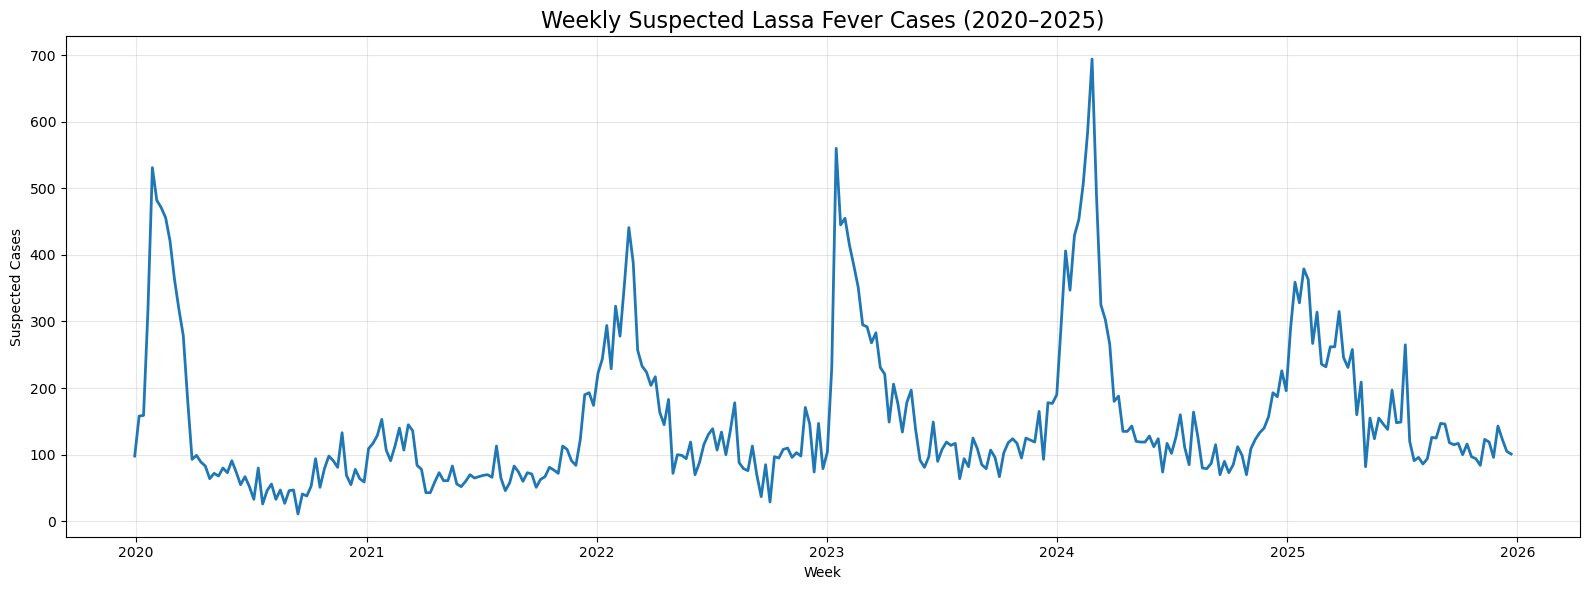

In [61]:
# WEEKLY SUSPECTED CASES

plt.figure(figsize=(16,6))

plt.plot(
    df["week_start_date"],
    df["suspected_cases"],
    linewidth=2
)

plt.title("Weekly Suspected Lassa Fever Cases (2020–2025)", fontsize=16)

plt.xlabel("Week")

plt.ylabel("Suspected Cases")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Weekly Deaths

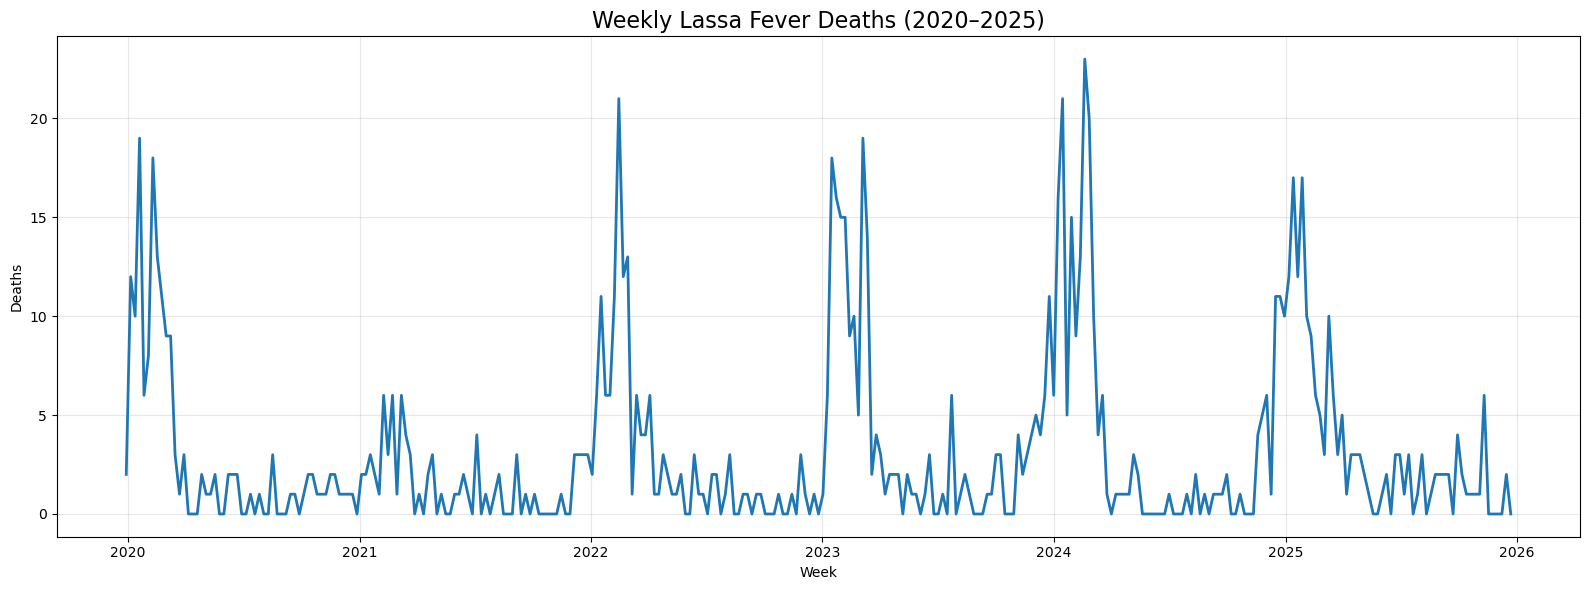

In [62]:
# WEEKLY DEATHS

plt.figure(figsize=(16,6))

plt.plot(
    df["week_start_date"],
    df["deaths"],
    linewidth=2
)

plt.title("Weekly Lassa Fever Deaths (2020–2025)", fontsize=16)

plt.xlabel("Week")

plt.ylabel("Deaths")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Distribution of Confirmed Cases

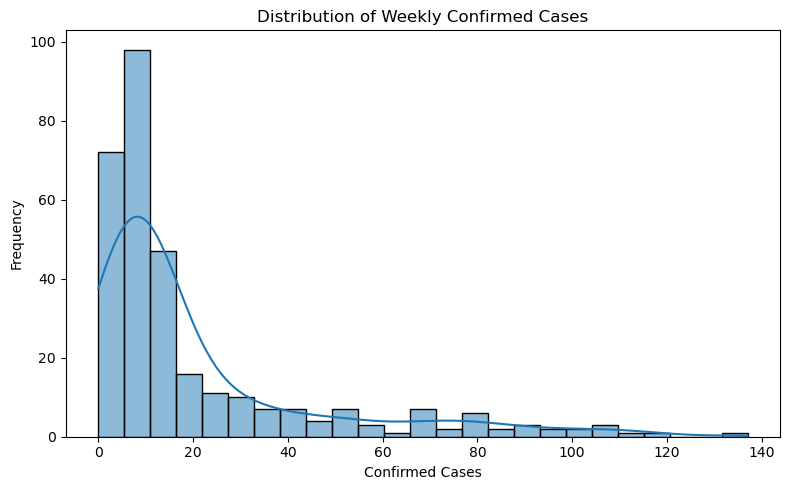

In [63]:
# DISTRIBUTION OF CONFIRMED CASES

plt.figure(figsize=(8,5))

sns.histplot(
    df["confirmed_cases"],
    bins=25,
    kde=True
)

plt.title("Distribution of Weekly Confirmed Cases")

plt.xlabel("Confirmed Cases")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

## Correlation Matrix

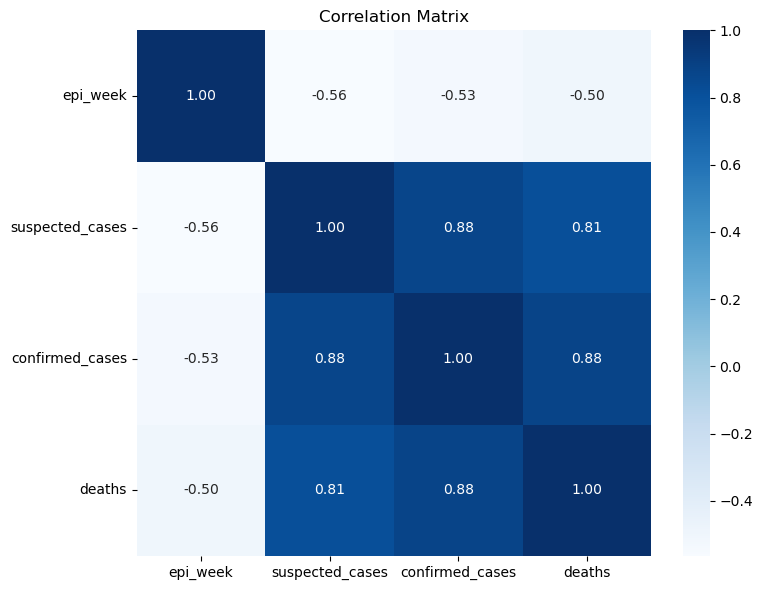

In [64]:
# CORRELATION MATRIX

corr = df[
    [
        "epi_week",
        "suspected_cases",
        "confirmed_cases",
        "deaths"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

## Boxplots

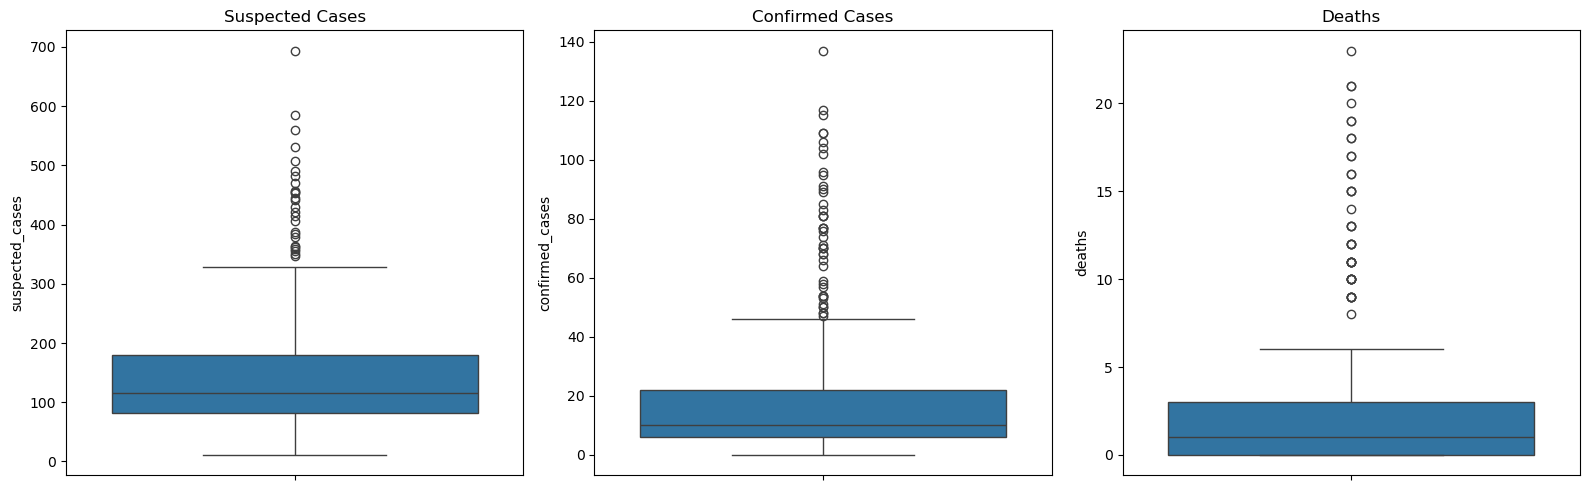

In [65]:
# BOXPLOTS

fig, ax = plt.subplots(1,3, figsize=(16,5))

sns.boxplot(y=df["suspected_cases"], ax=ax[0])
ax[0].set_title("Suspected Cases")

sns.boxplot(y=df["confirmed_cases"], ax=ax[1])
ax[1].set_title("Confirmed Cases")

sns.boxplot(y=df["deaths"], ax=ax[2])
ax[2].set_title("Deaths")

plt.tight_layout()

plt.show()

## Preserve the cleaned data

In [66]:
# CREATE A WORKING COPY AND CONFIRM CHRONOLOGICAL ORDER

model_df = df.copy()

model_df = (
    model_df
    .sort_values(["epi_year", "epi_week"])
    .reset_index(drop=True)
)

print("Working dataset shape:", model_df.shape)
display(model_df.head())

Working dataset shape: (313, 7)


,week_start_date,week_end_date,epi_year,epi_week,suspected_cases,confirmed_cases,deaths
0,2019-12-30,2020-01-05,2020,1,98,18,2
1,2020-01-06,2020-01-12,2020,2,158,64,12
2,2020-01-13,2020-01-19,2020,3,159,81,10
3,2020-01-20,2020-01-26,2020,4,318,95,19
4,2020-01-27,2020-02-02,2020,5,531,104,6


## Calendar features

In [67]:
# CALENDAR AND SEASONAL FEATURES
model_df["month"] = model_df["week_start_date"].dt.month
model_df["quarter"] = model_df["week_start_date"].dt.quarter

# Nigerian Lassa fever season indicator:
# dry season coded as November-April
model_df["dry_season"] = model_df["month"].isin(
    [11, 12, 1, 2, 3, 4]
).astype(int)

# Cyclical encoding of epidemiological week
model_df["week_sin"] = np.sin(
    2 * np.pi * model_df["epi_week"] / 52
)

model_df["week_cos"] = np.cos(
    2 * np.pi * model_df["epi_week"] / 52
)

display(
    model_df[
        [
            "week_start_date",
            "epi_year",
            "epi_week",
            "month",
            "quarter",
            "dry_season",
            "week_sin",
            "week_cos"
        ]
    ].head()
)

,week_start_date,epi_year,epi_week,month,quarter,dry_season,week_sin,week_cos
0,2019-12-30,2020,1,12,4,1,0.120537,0.992709
1,2020-01-06,2020,2,1,1,1,0.239316,0.970942
2,2020-01-13,2020,3,1,1,1,0.354605,0.935016
3,2020-01-20,2020,4,1,1,1,0.464723,0.885456
4,2020-01-27,2020,5,1,1,1,0.568065,0.822984


## Lag features

In [68]:
# TEMPORAL LAG FEATURES
lag_periods = [1, 2, 3, 4, 52]

for lag in lag_periods:
    model_df[f"confirmed_lag_{lag}"] = (
        model_df["confirmed_cases"].shift(lag)
    )

    model_df[f"suspected_lag_{lag}"] = (
        model_df["suspected_cases"].shift(lag)
    )

    model_df[f"deaths_lag_{lag}"] = (
        model_df["deaths"].shift(lag)
    )

lag_columns = [
    column for column in model_df.columns
    if "_lag_" in column
]

print("Lag features created:", len(lag_columns))
print(lag_columns)

Lag features created: 15
['confirmed_lag_1', 'suspected_lag_1', 'deaths_lag_1', 'confirmed_lag_2', 'suspected_lag_2', 'deaths_lag_2', 'confirmed_lag_3', 'suspected_lag_3', 'deaths_lag_3', 'confirmed_lag_4', 'suspected_lag_4', 'deaths_lag_4', 'confirmed_lag_52', 'suspected_lag_52', 'deaths_lag_52']


## Rolling-window features

The rolling calculations is shifted by one week. Without the shift, the current confirmed case count would enter its own predictor and create data leakage.

In [69]:
# ROLLING-WINDOW FEATURES

for window in [4, 8]:
    model_df[f"confirmed_roll_mean_{window}"] = (
        model_df["confirmed_cases"]
        .shift(1)
        .rolling(window=window)
        .mean()
    )

    model_df[f"confirmed_roll_std_{window}"] = (
        model_df["confirmed_cases"]
        .shift(1)
        .rolling(window=window)
        .std()
    )

    model_df[f"suspected_roll_mean_{window}"] = (
        model_df["suspected_cases"]
        .shift(1)
        .rolling(window=window)
        .mean()
    )

    model_df[f"suspected_roll_std_{window}"] = (
        model_df["suspected_cases"]
        .shift(1)
        .rolling(window=window)
        .std()
    )

    model_df[f"deaths_roll_mean_{window}"] = (
        model_df["deaths"]
        .shift(1)
        .rolling(window=window)
        .mean()
    )

    model_df[f"deaths_roll_std_{window}"] = (
        model_df["deaths"]
        .shift(1)
        .rolling(window=window)
        .std()
    )

rolling_columns = [
    column for column in model_df.columns
    if "_roll_" in column
]

print("Rolling features created:", len(rolling_columns))
print(rolling_columns)

Rolling features created: 12
['confirmed_roll_mean_4', 'confirmed_roll_std_4', 'suspected_roll_mean_4', 'suspected_roll_std_4', 'deaths_roll_mean_4', 'deaths_roll_std_4', 'confirmed_roll_mean_8', 'confirmed_roll_std_8', 'suspected_roll_mean_8', 'suspected_roll_std_8', 'deaths_roll_mean_8', 'deaths_roll_std_8']


## Define the outbreak-status target

The outbreak threshold is estimated using the training period only. Using all years would allow information from 2024 and 2025 to influence model development.

In [70]:
# CREATE BINARY OUTBREAK TARGET

training_period = model_df[
    model_df["epi_year"].between(2020, 2023)
]

outbreak_threshold = training_period[
    "confirmed_cases"
].quantile(0.75)

model_df["outbreak_status"] = (
    model_df["confirmed_cases"] >= outbreak_threshold
).astype(int)

print(
    f"Training-derived outbreak threshold: "
    f"{outbreak_threshold:.2f} confirmed cases"
)

print("\nOutbreak class distribution:")
print(model_df["outbreak_status"].value_counts())

print("\nOutbreak class percentage:")
print(
    model_df["outbreak_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training-derived outbreak threshold: 18.00 confirmed cases

Outbreak class distribution:
outbreak_status
0    223
1     90
Name: count, dtype: int64

Outbreak class percentage:
outbreak_status
0    71.25
1    28.75
Name: proportion, dtype: float64


## Remove rows affected by lag generation

The 52-week lag produces missing values for the first 52 observations. These rows cannot be used for model training.

In [71]:
# REMOVE INCOMPLETE FEATURE ROWS

feature_columns = [
    "epi_week",
    "month",
    "quarter",
    "dry_season",
    "week_sin",
    "week_cos"
] + lag_columns + rolling_columns

required_columns = (
    feature_columns
    + ["confirmed_cases", "outbreak_status"]
)

model_df_complete = (
    model_df
    .dropna(subset=required_columns)
    .reset_index(drop=True)
)

print("Shape before removing incomplete rows:", model_df.shape)
print("Shape after removing incomplete rows:", model_df_complete.shape)
print(
    "Rows removed:",
    model_df.shape[0] - model_df_complete.shape[0]
)

display(model_df_complete.head())

Shape before removing incomplete rows: (313, 40)
Shape after removing incomplete rows: (261, 40)
Rows removed: 52


,week_start_date,week_end_date,epi_year,epi_week,suspected_cases,confirmed_cases,deaths,month,quarter,dry_season,week_sin,week_cos,confirmed_lag_1,suspected_lag_1,deaths_lag_1,confirmed_lag_2,suspected_lag_2,deaths_lag_2,confirmed_lag_3,suspected_lag_3,deaths_lag_3,confirmed_lag_4,suspected_lag_4,deaths_lag_4,confirmed_lag_52,suspected_lag_52,deaths_lag_52,confirmed_roll_mean_4,confirmed_roll_std_4,suspected_roll_mean_4,suspected_roll_std_4,deaths_roll_mean_4,deaths_roll_std_4,confirmed_roll_mean_8,confirmed_roll_std_8,suspected_roll_mean_8,suspected_roll_std_8,deaths_roll_mean_8,deaths_roll_std_8,outbreak_status
0,2020-12-28,2021-01-03,2020,53,59,8,0,12,4,1,0.120537,0.992709,6.0,64.0,1.0,12.0,78.0,1.0,5.0,55.0,1.0,4.0,69.0,1.0,18.0,98.0,2.0,6.75,3.593976,66.50,9.609024,1.00,0.000000,6.250,3.240370,83.625,24.365887,1.250,0.462910,0
1,2021-01-04,2021-01-10,2021,1,109,9,2,1,1,1,0.120537,0.992709,8.0,59.0,0.0,6.0,64.0,1.0,12.0,78.0,1.0,5.0,55.0,1.0,64.0,158.0,12.0,7.75,3.095696,64.00,10.033278,0.75,0.500000,6.625,3.248626,78.750,24.972842,1.125,0.640870,0
2,2021-01-11,2021-01-17,2021,2,117,14,2,1,1,1,0.239316,0.970942,9.0,109.0,2.0,8.0,59.0,0.0,6.0,64.0,1.0,12.0,78.0,1.0,81.0,159.0,10.0,8.75,2.500000,77.50,22.487033,1.00,0.816497,7.500,2.725541,81.000,26.965587,1.250,0.707107,0
3,2021-01-18,2021-01-24,2021,3,129,17,3,1,1,1,0.354605,0.935016,14.0,117.0,2.0,9.0,109.0,2.0,8.0,59.0,0.0,6.0,64.0,1.0,95.0,318.0,19.0,9.25,3.403430,87.25,29.981939,1.25,0.957427,8.000,3.505098,85.500,29.818499,1.250,0.707107,0
4,2021-01-25,2021-01-31,2021,4,153,14,2,1,1,1,0.464723,0.885456,17.0,129.0,3.0,14.0,117.0,2.0,9.0,109.0,2.0,8.0,59.0,0.0,104.0,531.0,6.0,12.00,4.242641,103.50,30.784195,1.75,1.258306,9.375,4.596194,85.000,28.928483,1.375,0.916125,0


## Check for leakage and missing values

In [72]:
# FEATURE VALIDATION

forbidden_predictors = {
    "confirmed_cases",
    "suspected_cases",
    "deaths",
    "outbreak_status",
    "week_start_date",
    "week_end_date"
}

leakage_columns = forbidden_predictors.intersection(
    feature_columns
)

print("Potential leakage columns:", leakage_columns)

missing_feature_values = (
    model_df_complete[feature_columns]
    .isna()
    .sum()
    .sum()
)

print("Missing values in final predictors:", missing_feature_values)
print("Number of predictors:", len(feature_columns))

Potential leakage columns: set()
Missing values in final predictors: 0
Number of predictors: 33


## Chronological dataset partitioning

In [73]:
# CHRONOLOGICAL TRAIN-VALIDATION-TEST SPLIT

train_df = model_df_complete[
    model_df_complete["epi_year"].between(2020, 2023)
].copy()

validation_df = model_df_complete[
    model_df_complete["epi_year"] == 2024
].copy()

test_df = model_df_complete[
    model_df_complete["epi_year"] == 2025
].copy()

print("Training observations:", len(train_df))
print("Validation observations:", len(validation_df))
print("Testing observations:", len(test_df))

print("\nTraining period:")
print(
    train_df["week_start_date"].min(),
    "to",
    train_df["week_end_date"].max()
)

print("\nValidation period:")
print(
    validation_df["week_start_date"].min(),
    "to",
    validation_df["week_end_date"].max()
)

print("\nTesting period:")
print(
    test_df["week_start_date"].min(),
    "to",
    test_df["week_end_date"].max()
)

Training observations: 157
Validation observations: 52
Testing observations: 52

Training period:
2020-12-28 00:00:00 to 2023-12-31 00:00:00

Validation period:
2024-01-01 00:00:00 to 2024-12-29 00:00:00

Testing period:
2024-12-30 00:00:00 to 2025-12-28 00:00:00


## Create regression and classification matrices

In [74]:
# REGRESSION DATA

X_train_reg = train_df[feature_columns]
y_train_reg = train_df["confirmed_cases"]

X_val_reg = validation_df[feature_columns]
y_val_reg = validation_df["confirmed_cases"]

X_test_reg = test_df[feature_columns]
y_test_reg = test_df["confirmed_cases"]



# CLASSIFICATION DATA

X_train_cls = train_df[feature_columns]
y_train_cls = train_df["outbreak_status"]

X_val_cls = validation_df[feature_columns]
y_val_cls = validation_df["outbreak_status"]

X_test_cls = test_df[feature_columns]
y_test_cls = test_df["outbreak_status"]


print("Regression training shape:", X_train_reg.shape)
print("Regression validation shape:", X_val_reg.shape)
print("Regression testing shape:", X_test_reg.shape)

print("\nClassification training classes:")
print(y_train_cls.value_counts())

print("\nClassification validation classes:")
print(y_val_cls.value_counts())

print("\nClassification testing classes:")
print(y_test_cls.value_counts())

Regression training shape: (157, 33)
Regression validation shape: (52, 33)
Regression testing shape: (52, 33)

Classification training classes:
outbreak_status
0    115
1     42
Name: count, dtype: int64

Classification validation classes:
outbreak_status
0    35
1    17
Name: count, dtype: int64

Classification testing classes:
outbreak_status
0    34
1    18
Name: count, dtype: int64


## Save the engineered dataset

In [75]:
# SAVE MODEL-READY DATASET

model_df_complete.to_csv(
    "Lassa_Fever/lassa_fever_engineered.csv",
    index=False
)

print("Engineered dataset saved successfully.")

Engineered dataset saved successfully.


## Define the regression evaluation function

In [76]:
# REGRESSION EVALUATION FUNCTION

def safe_mape(y_true, y_pred, epsilon=1e-6):
    """
    Calculate MAPE while preventing division by zero.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return np.mean(
        np.abs((y_true - y_pred) / (y_true + epsilon))
    ) * 100


def evaluate_regression_model(
    model_name,
    y_true,
    y_pred
):
    """
    Calculate regression performance metrics.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = safe_mape(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R²": r2
    }

## Define the baseline regression models

In [145]:
# FINAL OPTIMIZED REGRESSION HYPERPARAMETERS
# USED FOR THE RESULTS REPORTED IN THE DISSERTATION

# Random Forest Regressor
rf_params = {
    "n_estimators": 440,
    "max_depth": 17,
    "min_samples_split": 15,
    "min_samples_leaf": 7,
    "max_features": None
}

# Support Vector Regressor
svr_params = {
    "C": 197.77052112083078,
    "gamma": 0.0035994905420770763,
    "epsilon": 0.6748804927212108
}

# XGBoost Regressor
xgb_params = {
    "n_estimators": 226,
    "learning_rate": 0.032475405190194276,
    "max_depth": 2,
    "min_child_weight": 9,
    "subsample": 0.9250511936940967,
    "colsample_bytree": 0.959155520517157,
    "gamma": 4.529557578496063,
    "reg_alpha": 0.004354729901464806,
    "reg_lambda": 9.925268620085738
}

print("Final dissertation regression hyperparameters loaded successfully.")

Final dissertation regression hyperparameters loaded successfully.


## Train and evaluate on the validation set

In [146]:
# TRAIN BASELINE REGRESSION MODELS

baseline_regression_results = []
validation_predictions = {}
trained_regression_models = {}

for model_name, model in regression_models.items():

    print(f"Training {model_name}...")

    model.fit(
        X_train_reg,
        y_train_reg
    )

    y_val_pred = model.predict(X_val_reg)

    # Confirmed case counts cannot be negative
    y_val_pred = np.clip(y_val_pred, 0, None)

    results = evaluate_regression_model(
        model_name=model_name,
        y_true=y_val_reg,
        y_pred=y_val_pred
    )

    baseline_regression_results.append(results)

    validation_predictions[model_name] = y_val_pred
    trained_regression_models[model_name] = model

print("\nBaseline regression training completed.")

Training Linear Regression...
Training Support Vector Regressor...
Training Random Forest Regressor...
Training XGBoost Regressor...

Baseline regression training completed.


## Display the validation results

In [147]:
# BASELINE REGRESSION RESULTS

baseline_regression_results_df = pd.DataFrame(
    baseline_regression_results
)

baseline_regression_results_df = (
    baseline_regression_results_df
    .sort_values("RMSE")
    .reset_index(drop=True)
)

baseline_regression_results_df[
    ["MAE", "RMSE", "MAPE (%)", "R²"]
] = baseline_regression_results_df[
    ["MAE", "RMSE", "MAPE (%)", "R²"]
].round(4)

display(baseline_regression_results_df)

,Model,MAE,RMSE,MAPE (%),R²
0,Random Forest Regressor,7.6284,12.0227,49.8873,0.8111
1,XGBoost Regressor,8.2701,14.0030,54.6920,0.7437
2,Linear Regression,13.4620,24.6100,82.0622,0.2084
3,Support Vector Regressor,14.9352,26.0750,51.7317,0.1113


## Compare actual and predicted validation values

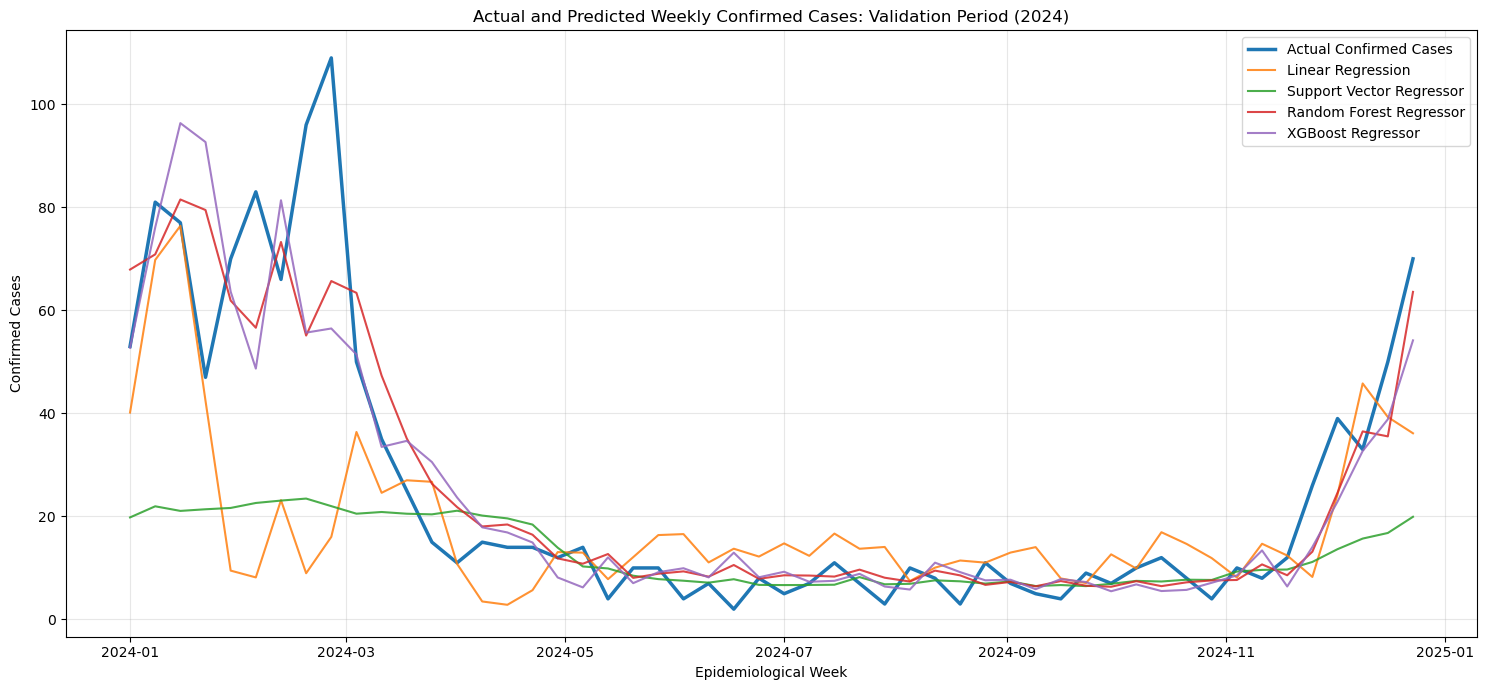

In [148]:
# ACTUAL VS PREDICTED VALIDATION CASE COUNTS

plt.figure(figsize=(15, 7))

plt.plot(
    validation_df["week_start_date"],
    y_val_reg.values,
    label="Actual Confirmed Cases",
    linewidth=2.5
)

for model_name, predictions in validation_predictions.items():
    plt.plot(
        validation_df["week_start_date"],
        predictions,
        label=model_name,
        linewidth=1.5,
        alpha=0.85
    )

plt.title(
    "Actual and Predicted Weekly Confirmed Cases: "
    "Validation Period (2024)"
)

plt.xlabel("Epidemiological Week")
plt.ylabel("Confirmed Cases")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Create individual model plots

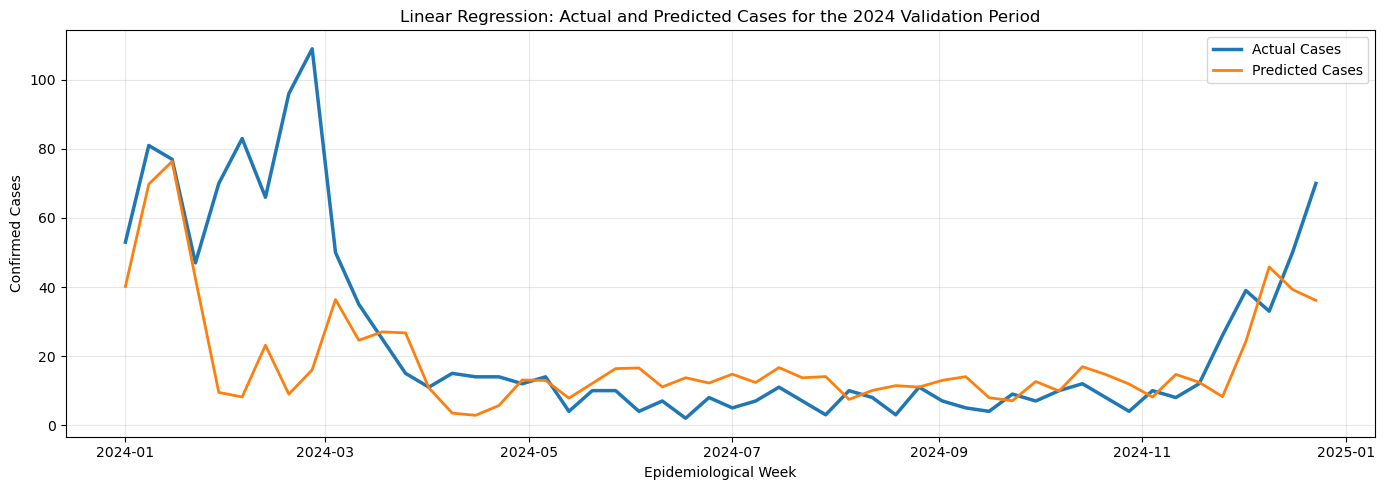

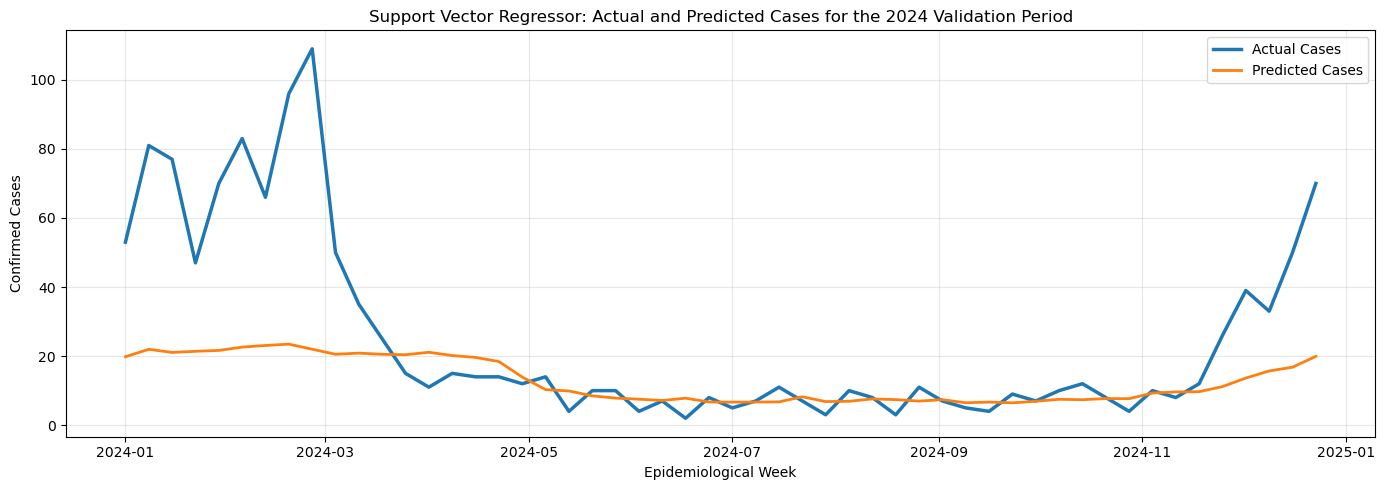

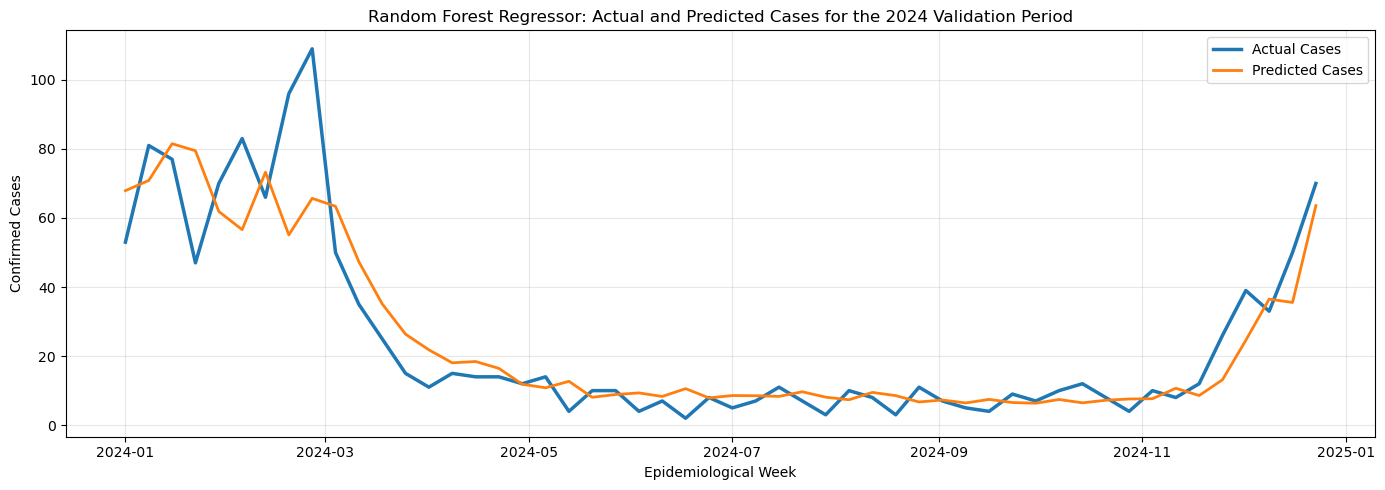

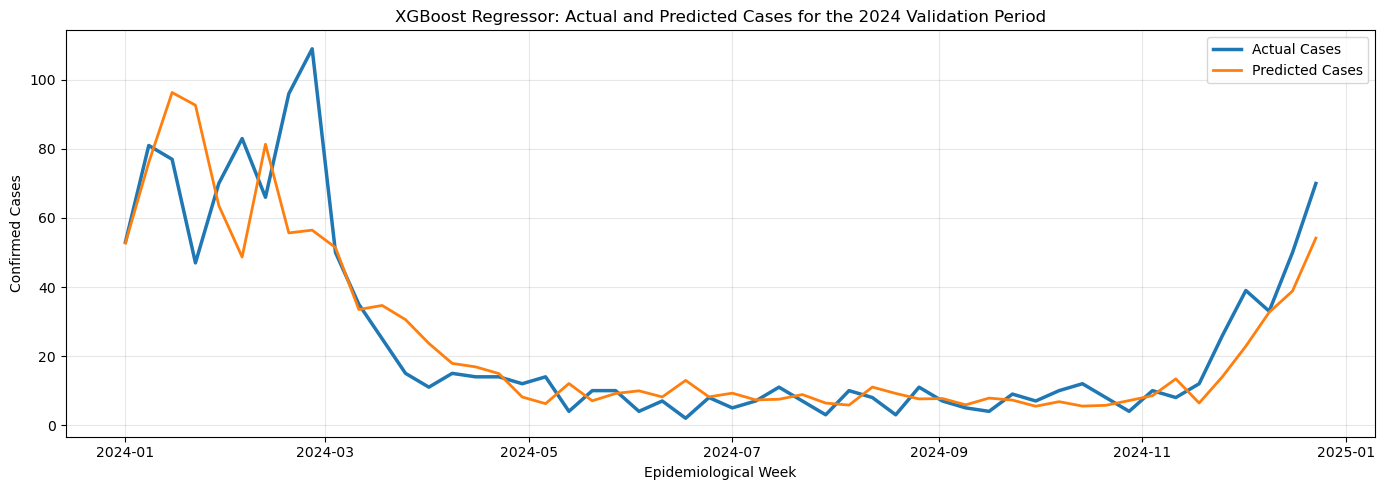

In [149]:
# INDIVIDUAL VALIDATION PLOTS

for model_name, predictions in validation_predictions.items():

    plt.figure(figsize=(14, 5))

    plt.plot(
        validation_df["week_start_date"],
        y_val_reg.values,
        label="Actual Cases",
        linewidth=2.5
    )

    plt.plot(
        validation_df["week_start_date"],
        predictions,
        label="Predicted Cases",
        linewidth=2
    )

    plt.title(
        f"{model_name}: Actual and Predicted Cases "
        f"for the 2024 Validation Period"
    )

    plt.xlabel("Epidemiological Week")
    plt.ylabel("Confirmed Cases")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [82]:
baseline_regression_results_df.to_csv(
    "Lassa_Fever/baseline_regression_validation_results.csv",
    index=False
)

print("Baseline regression results saved successfully.")

Baseline regression results saved successfully.


In [83]:
np.clip(y_val_pred, 0, None)

array([52.735413 , 76.0927   , 96.33855  , 92.659584 , 63.617397 ,
       48.69339  , 81.36193  , 55.67552  , 56.479412 , 51.431347 ,
       33.495403 , 34.664368 , 30.553787 , 23.67794  , 17.883255 ,
       16.88589  , 14.935841 ,  8.150219 ,  6.223173 , 12.053232 ,
        7.047336 ,  9.172758 ,  9.94438  ,  8.168279 , 12.966021 ,
        8.187141 ,  9.261428 ,  7.3189354,  7.498573 ,  8.859427 ,
        6.3947763,  5.8074684, 11.024592 ,  9.185287 ,  7.5975657,
        7.7142553,  5.880055 ,  7.8410935,  7.258614 ,  5.4754953,
        6.803147 ,  5.516664 ,  5.742277 ,  7.1217422,  8.542771 ,
       13.401535 ,  6.4037337, 14.056885 , 22.869024 , 32.692238 ,
       38.849155 , 54.17485  ], dtype=float32)

## Create the Optuna regression objective

In [150]:
# OPTUNA OBJECTIVE FOR REGRESSION MODELS

def regression_objective(trial, model_name):

    if model_name == "Random Forest Regressor":

        model = RandomForestRegressor(
            n_estimators=trial.suggest_int(
                "n_estimators", 100, 800
            ),
            max_depth=trial.suggest_int(
                "max_depth", 3, 25
            ),
            min_samples_split=trial.suggest_int(
                "min_samples_split", 2, 15
            ),
            min_samples_leaf=trial.suggest_int(
                "min_samples_leaf", 1, 10
            ),
            max_features=trial.suggest_categorical(
                "max_features",
                ["sqrt", "log2", None]
            ),
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif model_name == "Support Vector Regressor":

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(
                kernel="rbf",
                C=trial.suggest_float(
                    "C", 1e-2, 1e3, log=True
                ),
                gamma=trial.suggest_float(
                    "gamma", 1e-4, 1.0, log=True
                ),
                epsilon=trial.suggest_float(
                    "epsilon", 0.01, 1.0, log=True
                )
            ))
        ])

    elif model_name == "XGBoost Regressor":

        model = XGBRegressor(
            n_estimators=trial.suggest_int(
                "n_estimators", 100, 800
            ),
            learning_rate=trial.suggest_float(
                "learning_rate", 0.01, 0.3, log=True
            ),
            max_depth=trial.suggest_int(
                "max_depth", 2, 10
            ),
            min_child_weight=trial.suggest_int(
                "min_child_weight", 1, 10
            ),
            subsample=trial.suggest_float(
                "subsample", 0.6, 1.0
            ),
            colsample_bytree=trial.suggest_float(
                "colsample_bytree", 0.6, 1.0
            ),
            gamma=trial.suggest_float(
                "gamma", 0.0, 5.0
            ),
            reg_alpha=trial.suggest_float(
                "reg_alpha", 1e-8, 10.0, log=True
            ),
            reg_lambda=trial.suggest_float(
                "reg_lambda", 1e-8, 10.0, log=True
            ),
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    else:
        raise ValueError(
            f"Unsupported model name: {model_name}"
        )

    model.fit(
        X_train_reg,
        y_train_reg
    )

    y_val_pred = model.predict(X_val_reg)

    y_val_pred = np.clip(
        y_val_pred,
        0,
        None
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val_reg,
            y_val_pred
        )
    )

    return rmse

## Run Optuna optimization

This is to performs 100 trials per regression model, consistent with my methodology.

In [151]:
# RUN OPTUNA REGRESSION OPTIMIZATION

optuna.logging.set_verbosity(
    optuna.logging.WARNING
)

regression_models_to_optimize = [
    "Random Forest Regressor",
    "Support Vector Regressor",
    "XGBoost Regressor"
]

regression_studies = {}

for model_name in regression_models_to_optimize:

    print(f"\nOptimizing {model_name}...")

    study = optuna.create_study(
        direction="minimize",
        study_name=model_name
    )

    study.optimize(
        lambda trial: regression_objective(
            trial,
            model_name
        ),
        n_trials=100,
        show_progress_bar=True
    )

    regression_studies[model_name] = study

    print(
        f"Best validation RMSE: "
        f"{study.best_value:.4f}"
    )

    print("Best parameters:")
    print(study.best_params)


Optimizing Random Forest Regressor...


  0%|          | 0/100 [00:00<?, ?it/s]

Best validation RMSE: 10.6797
Best parameters:
{'n_estimators': 236, 'max_depth': 3, 'min_samples_split': 13, 'min_samples_leaf': 8, 'max_features': None}

Optimizing Support Vector Regressor...


  0%|          | 0/100 [00:00<?, ?it/s]

Best validation RMSE: 14.6273
Best parameters:
{'C': 237.1311948667828, 'gamma': 0.003263612822369175, 'epsilon': 0.495344634005824}

Optimizing XGBoost Regressor...


  0%|          | 0/100 [00:00<?, ?it/s]

Best validation RMSE: 11.0980
Best parameters:
{'n_estimators': 371, 'learning_rate': 0.023503153348670782, 'max_depth': 2, 'min_child_weight': 10, 'subsample': 0.9405773273616606, 'colsample_bytree': 0.7900687726309066, 'gamma': 4.7473541566583135, 'reg_alpha': 5.647346256275414e-08, 'reg_lambda': 9.997767542993254}


In [ ]:
## Display the best hyperparameters

In [86]:
# BEST REGRESSION HYPERPARAMETERS

best_parameter_rows = []

for model_name, study in regression_studies.items():

    row = {
        "Model": model_name,
        "Best Validation RMSE": round(
            study.best_value,
            4
        ),
        "Best Parameters": study.best_params
    }

    best_parameter_rows.append(row)

best_regression_parameters_df = pd.DataFrame(
    best_parameter_rows
)

display(best_regression_parameters_df)

,Model,Best Validation RMSE,Best Parameters
0,Random Forest Regressor,10.7057,"{'n_estimators': 238, 'max_depth': 19, 'min_sa..."
1,Support Vector Regressor,14.6807,"{'C': 80.3211038241, 'gamma': 0.00718159257266..."
2,XGBoost Regressor,11.1710,"{'n_estimators': 117, 'learning_rate': 0.02980..."


## Build the optimized regression models

In [87]:
# BUILD OPTIMIZED REGRESSION MODELS

rf_params = regression_studies[
    "Random Forest Regressor"
].best_params

svr_params = regression_studies[
    "Support Vector Regressor"
].best_params

xgb_params = regression_studies[
    "XGBoost Regressor"
].best_params


optimized_regression_models = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Optimized Random Forest Regressor":
        RandomForestRegressor(
            **rf_params,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "Optimized Support Vector Regressor":
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(
                kernel="rbf",
                **svr_params
            ))
        ]),

    "Optimized XGBoost Regressor":
        XGBRegressor(
            **xgb_params,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
}

print("Optimized regression models created.")

Optimized regression models created.


## Merge Training and Validation Sets

Reason: There is one methodological issue in the code I previously wrote.

In [152]:
# COMBINE TRAINING AND VALIDATION DATA

X_train_final_reg = pd.concat(
    [X_train_reg, X_val_reg],
    axis=0
)

y_train_final_reg = pd.concat(
    [y_train_reg, y_val_reg],
    axis=0
)

print("Final Regression Training Shape")

print(X_train_final_reg.shape)

print(y_train_final_reg.shape)

Final Regression Training Shape
(209, 33)
(209,)


## Retrain Optimized Models

In [153]:
optimized_test_results = []

optimized_predictions = {}

trained_final_models = {}

In [154]:
# RESTORE BEST OPTUNA HYPERPARAMETERS

rf_params = {
    "n_estimators": 440,
    "max_depth": 17,
    "min_samples_split": 15,
    "min_samples_leaf": 7,
    "max_features": None
}

svr_params = {
    "C": 197.77052112083078,
    "gamma": 0.0035994905420770763,
    "epsilon": 0.6748804927212108
}

xgb_params = {
    "n_estimators": 226,
    "learning_rate": 0.032475405190194276,
    "max_depth": 2,
    "min_child_weight": 9,
    "subsample": 0.9250511936940967,
    "colsample_bytree": 0.959155520517157,
    "gamma": 4.529557578496063,
    "reg_alpha": 0.004354729901464806,
    "reg_lambda": 9.925268620085738
}

print("Best hyperparameters restored successfully.")

Best hyperparameters restored successfully.


In [155]:
X_train_reg
X_val_reg
X_test_reg
y_train_reg
y_val_reg
y_test_reg

209    54
210    89
211    71
212    76
213    68
214    54
215    38
216    54
217    29
218    28
219    40
220    41
221    14
222    15
223    12
224    10
225    11
226    10
227     3
228    13
229     6
230     8
231    11
232     8
233    10
234     9
235    11
236    11
237    11
238     3
239     9
240    12
241     5
242     3
243    10
244    13
245    11
246    11
247     4
248    13
249    11
250     9
251    11
252    12
253    10
254    19
255    17
256    24
257    33
258    28
259    21
260    27
Name: confirmed_cases, dtype: int64

In [156]:
# COMBINE TRAINING AND VALIDATION DATA

X_train_final_reg = pd.concat(
    [X_train_reg, X_val_reg],
    axis=0
)

y_train_final_reg = pd.concat(
    [y_train_reg, y_val_reg],
    axis=0
)

print("Final Training Feature Shape:", X_train_final_reg.shape)
print("Final Training Target Shape:", y_train_final_reg.shape)

Final Training Feature Shape: (209, 33)
Final Training Target Shape: (209,)


## Train Final Regression Models

In [157]:
# TRAIN FINAL REGRESSION MODELS

linear_final = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

rf_final = RandomForestRegressor(
    **rf_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

svr_final = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(
        kernel="rbf",
        **svr_params
    ))
])

xgb_final = XGBRegressor(
    **xgb_params,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

final_regression_models = {
    "Linear Regression": linear_final,
    "Random Forest Regressor": rf_final,
    "Support Vector Regressor": svr_final,
    "XGBoost Regressor": xgb_final
}

for model_name, model in final_regression_models.items():
    model.fit(X_train_final_reg, y_train_final_reg)
    print(f"{model_name} trained successfully.")

Linear Regression trained successfully.
Random Forest Regressor trained successfully.
Support Vector Regressor trained successfully.
XGBoost Regressor trained successfully.


## Generate 2025 Test Predictions

In [158]:
# GENERATE FINAL TEST PREDICTIONS

final_regression_predictions = {}

for model_name, model in final_regression_models.items():

    predictions = model.predict(X_test_reg)

    # Weekly case counts cannot be negative
    predictions = np.clip(predictions, 0, None)

    final_regression_predictions[model_name] = predictions

print("Final test predictions generated successfully.")

Final test predictions generated successfully.


## Evaluate Final Regression Performance

In [159]:
# FINAL REGRESSION EVALUATION

final_regression_results = []

for model_name, predictions in final_regression_predictions.items():

    results = evaluate_regression_model(
        model_name=model_name,
        y_true=y_test_reg,
        y_pred=predictions
    )

    final_regression_results.append(results)

final_regression_results_df = pd.DataFrame(
    final_regression_results
)

final_regression_results_df = (
    final_regression_results_df
    .sort_values("RMSE")
    .reset_index(drop=True)
)

final_regression_results_df[
    ["MAE", "RMSE", "MAPE (%)", "R²"]
] = final_regression_results_df[
    ["MAE", "RMSE", "MAPE (%)", "R²"]
].round(4)

display(final_regression_results_df)

,Model,MAE,RMSE,MAPE (%),R²
0,Support Vector Regressor,6.3546,8.7611,45.9762,0.8148
1,Linear Regression,7.2465,9.4976,49.7240,0.7824
2,XGBoost Regressor,6.4808,9.7120,44.9871,0.7724
3,Random Forest Regressor,6.9055,10.4708,44.5906,0.7355


## Save the Final Results

In [160]:
# SAVE FINAL REGRESSION RESULTS

final_regression_results_df.to_csv(
    "Lassa_Fever/final_regression_test_results.csv",
    index=False
)

print("Final regression test results saved successfully.")

Final regression test results saved successfully.


In [161]:
print(list(X_train_final_reg.columns))
print(list(X_test_reg.columns))

['epi_week', 'month', 'quarter', 'dry_season', 'week_sin', 'week_cos', 'confirmed_lag_1', 'suspected_lag_1', 'deaths_lag_1', 'confirmed_lag_2', 'suspected_lag_2', 'deaths_lag_2', 'confirmed_lag_3', 'suspected_lag_3', 'deaths_lag_3', 'confirmed_lag_4', 'suspected_lag_4', 'deaths_lag_4', 'confirmed_lag_52', 'suspected_lag_52', 'deaths_lag_52', 'confirmed_roll_mean_4', 'confirmed_roll_std_4', 'suspected_roll_mean_4', 'suspected_roll_std_4', 'deaths_roll_mean_4', 'deaths_roll_std_4', 'confirmed_roll_mean_8', 'confirmed_roll_std_8', 'suspected_roll_mean_8', 'suspected_roll_std_8', 'deaths_roll_mean_8', 'deaths_roll_std_8']
['epi_week', 'month', 'quarter', 'dry_season', 'week_sin', 'week_cos', 'confirmed_lag_1', 'suspected_lag_1', 'deaths_lag_1', 'confirmed_lag_2', 'suspected_lag_2', 'deaths_lag_2', 'confirmed_lag_3', 'suspected_lag_3', 'deaths_lag_3', 'confirmed_lag_4', 'suspected_lag_4', 'deaths_lag_4', 'confirmed_lag_52', 'suspected_lag_52', 'deaths_lag_52', 'confirmed_roll_mean_4', 'conf

In [162]:
print(X_train_final_reg.shape)
print(X_test_reg.shape)

(209, 33)
(52, 33)


In [163]:
print("Training target:")
print(y_train_final_reg.head())

print("\nTesting target:")
print(y_test_reg.head())

Training target:
0     8
1     9
2    14
3    17
4    14
Name: confirmed_cases, dtype: int64

Testing target:
209    54
210    89
211    71
212    76
213    68
Name: confirmed_cases, dtype: int64


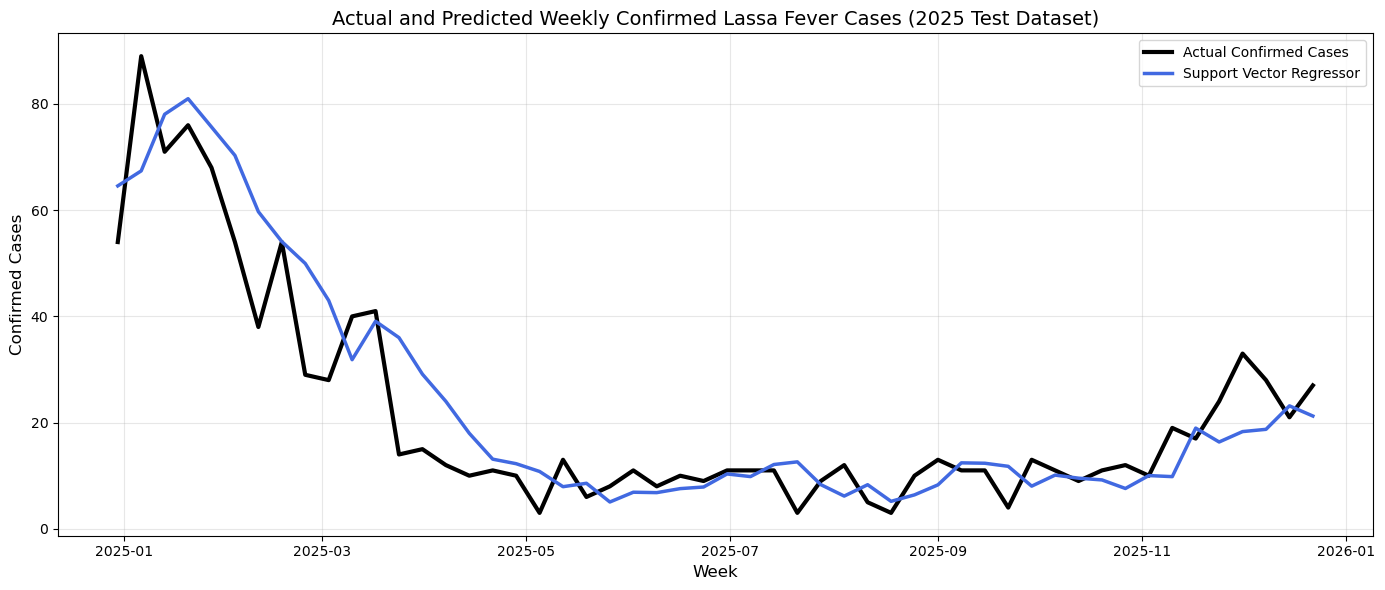

In [164]:
# ACTUAL VS PREDICTED (BEST MODEL - SVR)

plt.figure(figsize=(14,6))

plt.plot(
    test_df["week_start_date"],
    y_test_reg,
    linewidth=3,
    color="black",
    label="Actual Confirmed Cases"
)

plt.plot(
    test_df["week_start_date"],
    final_regression_predictions["Support Vector Regressor"],
    linewidth=2.5,
    color="royalblue",
    label="Support Vector Regressor"
)

plt.title(
    "Actual and Predicted Weekly Confirmed Lassa Fever Cases (2025 Test Dataset)",
    fontsize=14
)

plt.xlabel("Week", fontsize=12)
plt.ylabel("Confirmed Cases", fontsize=12)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

## Define the classification evaluation function

In [165]:
# CLASSIFICATION EVALUATION FUNCTION

def evaluate_classification_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            y_prob
        )
    }

## Class weights

In [166]:
# CLASS IMBALANCE SETTINGS

negative_count = (y_train_cls == 0).sum()
positive_count = (y_train_cls == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Non-outbreak observations:", negative_count)
print("Outbreak observations:", positive_count)
print("XGBoost scale_pos_weight:", round(scale_pos_weight, 4))

Non-outbreak observations: 115
Outbreak observations: 42
XGBoost scale_pos_weight: 2.7381


## Baseline classification models

In [167]:
# BASELINE CLASSIFICATION MODELS

classification_models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost Classifier": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

print("Baseline classification models initialized.")

Baseline classification models initialized.


## Train and evaluate on the 2024 validation set

In [168]:
# TRAIN BASELINE CLASSIFICATION MODELS

baseline_classification_results = []
classification_predictions = {}
classification_probabilities = {}
trained_classification_models = {}

for model_name, model in classification_models.items():

    print(f"Training {model_name}...")

    model.fit(
        X_train_cls,
        y_train_cls
    )

    y_val_pred = model.predict(X_val_cls)

    y_val_prob = model.predict_proba(
        X_val_cls
    )[:, 1]

    results = evaluate_classification_model(
        model_name=model_name,
        y_true=y_val_cls,
        y_pred=y_val_pred,
        y_prob=y_val_prob
    )

    baseline_classification_results.append(results)
    classification_predictions[model_name] = y_val_pred
    classification_probabilities[model_name] = y_val_prob
    trained_classification_models[model_name] = model

print("Baseline classification training completed.")

Training Logistic Regression...
Training Support Vector Machine...
Training Random Forest Classifier...
Training XGBoost Classifier...
Baseline classification training completed.


## Display baseline validation results

In [169]:
# BASELINE CLASSIFICATION RESULTS

baseline_classification_results_df = pd.DataFrame(
    baseline_classification_results
)

baseline_classification_results_df = (
    baseline_classification_results_df
    .sort_values(
        ["F1-score", "ROC-AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

baseline_classification_results_df[
    metric_columns
] = baseline_classification_results_df[
    metric_columns
].round(4)

display(baseline_classification_results_df)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost Classifier,0.9231,0.8421,0.9412,0.8889,0.9815
1,Random Forest Classifier,0.8846,0.7895,0.8824,0.8333,0.9672
2,Logistic Regression,0.8654,0.7273,0.9412,0.8205,0.9580
3,Support Vector Machine,0.8654,0.7273,0.9412,0.8205,0.8992


## Random Forest Classifier Optimization

In [170]:
# RANDOM FOREST CLASSIFIER OPTUNA OBJECTIVE

def rf_classifier_objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)

    model.fit(
        X_train_cls,
        y_train_cls
    )

    pred = model.predict(X_val_cls)

    return f1_score(
        y_val_cls,
        pred
    )

## Optimization

In [171]:
# OPTIMIZE RANDOM FOREST CLASSIFIER

print("Optimizing Random Forest Classifier...")

rf_classifier_study = optuna.create_study(
    direction="maximize"
)

rf_classifier_study.optimize(
    rf_classifier_objective,
    n_trials=100,
    show_progress_bar=True
)

print()

print("Best Validation F1-score:",
      round(rf_classifier_study.best_value,4))

print()

print("Best Parameters:")

print(rf_classifier_study.best_params)

rf_classifier_params = rf_classifier_study.best_params

Optimizing Random Forest Classifier...


  0%|          | 0/100 [00:00<?, ?it/s]


Best Validation F1-score: 0.8889

Best Parameters:
{'n_estimators': 102, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': None}


## Display the Best Parameters

In [172]:
print("="*60)
print("OPTIMIZED RANDOM FOREST CLASSIFIER")
print("="*60)

print()

for key, value in rf_classifier_params.items():
    print(f"{key}: {value}")

OPTIMIZED RANDOM FOREST CLASSIFIER

n_estimators: 102
max_depth: 14
min_samples_split: 2
min_samples_leaf: 10
max_features: None


## Optimizing Support Vector Machine (SVM)

In [173]:
# SUPPORT VECTOR MACHINE OPTUNA OBJECTIVE

def svm_classifier_objective(trial):

    params = {
        "C": trial.suggest_float(
            "C",
            0.01,
            1000,
            log=True
        ),

        "gamma": trial.suggest_float(
            "gamma",
            1e-4,
            1,
            log=True
        ),

        "kernel": "rbf",

        "class_weight": "balanced",

        "probability": True,

        "random_state": RANDOM_STATE
    }

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(**params))
    ])

    model.fit(
        X_train_cls,
        y_train_cls
    )

    prediction = model.predict(X_val_cls)

    return f1_score(
        y_val_cls,
        prediction
    )

## Optimization

In [111]:
# OPTIMIZE SUPPORT VECTOR MACHINE

print("Optimizing Support Vector Machine...")

svm_classifier_study = optuna.create_study(
    direction="maximize"
)

svm_classifier_study.optimize(
    svm_classifier_objective,
    n_trials=100,
    show_progress_bar=True
)

print()

print("Best Validation F1-score:",
      round(svm_classifier_study.best_value,4))

print()

print("Best Parameters:")

print(svm_classifier_study.best_params)

svm_classifier_params = svm_classifier_study.best_params

Optimizing Support Vector Machine...


  0%|          | 0/100 [00:00<?, ?it/s]


Best Validation F1-score: 0.8205

Best Parameters:
{'C': 7.393479707408152, 'gamma': 0.004450281879460681}


## Display the Best Parameters

In [112]:
# DISPLAY OPTIMIZED SVM PARAMETERS

print("=" * 60)
print("OPTIMIZED SUPPORT VECTOR MACHINE")
print("=" * 60)

print()

for key, value in svm_classifier_params.items():
    print(f"{key}: {value}")

OPTIMIZED SUPPORT VECTOR MACHINE

C: 7.393479707408152
gamma: 0.004450281879460681


## Define the XGBoost Classification Objective

In [113]:
# XGBOOST CLASSIFIER OPTUNA OBJECTIVE

def xgb_classifier_objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            600
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            2,
            10
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0.0,
            5.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10.0,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-8,
            10.0,
            log=True
        ),

        "scale_pos_weight": scale_pos_weight,

        "eval_metric": "logloss",

        "random_state": RANDOM_STATE,

        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    model.fit(
        X_train_cls,
        y_train_cls
    )

    prediction = model.predict(X_val_cls)

    return f1_score(
        y_val_cls,
        prediction
    )

## XGBoost Optimization

In [114]:
# OPTIMIZE XGBOOST CLASSIFIER

print("Optimizing XGBoost Classifier...")

xgb_classifier_study = optuna.create_study(
    direction="maximize"
)

xgb_classifier_study.optimize(
    xgb_classifier_objective,
    n_trials=100,
    show_progress_bar=True
)

print()

print(
    "Best Validation F1-score:",
    round(xgb_classifier_study.best_value, 4)
)

print()

print("Best Parameters:")
print(xgb_classifier_study.best_params)

xgb_classifier_params = (
    xgb_classifier_study.best_params
)

Optimizing XGBoost Classifier...


  0%|          | 0/100 [00:00<?, ?it/s]


Best Validation F1-score: 0.8889

Best Parameters:
{'n_estimators': 551, 'learning_rate': 0.03364899070759068, 'max_depth': 2, 'min_child_weight': 2, 'subsample': 0.6273624166660232, 'colsample_bytree': 0.8189933402449616, 'gamma': 0.8666029087027377, 'reg_alpha': 7.707875597710012e-05, 'reg_lambda': 0.1639581877160087}


## Display the Best Parameters

In [115]:
# DISPLAY OPTIMIZED XGBOOST PARAMETERS

print("=" * 60)
print("OPTIMIZED XGBOOST CLASSIFIER")
print("=" * 60)

print()

for key, value in xgb_classifier_params.items():
    print(f"{key}: {value}")

OPTIMIZED XGBOOST CLASSIFIER

n_estimators: 551
learning_rate: 0.03364899070759068
max_depth: 2
min_child_weight: 2
subsample: 0.6273624166660232
colsample_bytree: 0.8189933402449616
gamma: 0.8666029087027377
reg_alpha: 7.707875597710012e-05
reg_lambda: 0.1639581877160087


## Logistic Regression Objective

In [116]:
# LOGISTIC REGRESSION OPTUNA OBJECTIVE

def logistic_classifier_objective(trial):

    penalty = trial.suggest_categorical(
        "penalty",
        ["l1", "l2"]
    )

    C = trial.suggest_float(
        "C",
        0.001,
        1000,
        log=True
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty=penalty,
            C=C,
            solver="liblinear",
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ])

    model.fit(
        X_train_cls,
        y_train_cls
    )

    prediction = model.predict(X_val_cls)

    return f1_score(
        y_val_cls,
        prediction,
        zero_division=0
    )

## Logistic Regression Optimization

In [117]:
# OPTIMIZE LOGISTIC REGRESSION

print("Optimizing Logistic Regression...")

logistic_classifier_study = optuna.create_study(
    direction="maximize"
)

logistic_classifier_study.optimize(
    logistic_classifier_objective,
    n_trials=100,
    show_progress_bar=True
)

print(
    "\nBest Validation F1-score:",
    round(logistic_classifier_study.best_value, 4)
)

print("\nBest Parameters:")
print(logistic_classifier_study.best_params)

logistic_classifier_params = (
    logistic_classifier_study.best_params
)

Optimizing Logistic Regression...


  0%|          | 0/100 [00:00<?, ?it/s]


Best Validation F1-score: 0.8571

Best Parameters:
{'penalty': 'l1', 'C': 0.01639951985747382}


## Display the Optimized Parameters

In [118]:
# DISPLAY OPTIMIZED LOGISTIC REGRESSION PARAMETERS

print("=" * 60)
print("OPTIMIZED LOGISTIC REGRESSION")
print("=" * 60)

for key, value in logistic_classifier_params.items():
    print(f"{key}: {value}")

OPTIMIZED LOGISTIC REGRESSION
penalty: l1
C: 0.01639951985747382


## Combine Training and Validation Data

In [174]:
# COMBINE TRAINING AND VALIDATION CLASSIFICATION DATA

X_train_final_cls = pd.concat(
    [X_train_cls, X_val_cls],
    axis=0
)

y_train_final_cls = pd.concat(
    [y_train_cls, y_val_cls],
    axis=0
)

print("Final Classification Feature Shape:", X_train_final_cls.shape)
print("Final Classification Target Shape:", y_train_final_cls.shape)

print("\nCombined class distribution:")
print(y_train_final_cls.value_counts())

Final Classification Feature Shape: (209, 33)
Final Classification Target Shape: (209,)

Combined class distribution:
outbreak_status
0    150
1     59
Name: count, dtype: int64


## Recalculate Class Weight for Final XGBoost Training

In [175]:
# FINAL CLASS IMBALANCE RATIO

final_negative_count = (y_train_final_cls == 0).sum()
final_positive_count = (y_train_final_cls == 1).sum()

final_scale_pos_weight = (
    final_negative_count / final_positive_count
)

print("Final non-outbreak count:", final_negative_count)
print("Final outbreak count:", final_positive_count)
print(
    "Final scale_pos_weight:",
    round(final_scale_pos_weight, 4)
)

Final non-outbreak count: 150
Final outbreak count: 59
Final scale_pos_weight: 2.5424


## Build the Optimized Classification Models

In [176]:
# BUILD FINAL OPTIMIZED CLASSIFIERS

logistic_final = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty=logistic_classifier_params["penalty"],
        C=logistic_classifier_params["C"],
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

svm_final = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=svm_classifier_params["C"],
        gamma=svm_classifier_params["gamma"],
        class_weight="balanced",
        probability=True,
        random_state=RANDOM_STATE
    ))
])

rf_classifier_final = RandomForestClassifier(
    **rf_classifier_params,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_classifier_final = XGBClassifier(
    **xgb_classifier_params,
    scale_pos_weight=final_scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

final_classification_models = {
    "Logistic Regression": logistic_final,
    "Support Vector Machine": svm_final,
    "Random Forest Classifier": rf_classifier_final,
    "XGBoost Classifier": xgb_classifier_final
}

print("Final optimized classification models created.")

Final optimized classification models created.


## Train the Final Classifiers

In [177]:
# TRAIN FINAL CLASSIFICATION MODELS

for model_name, model in final_classification_models.items():

    model.fit(
        X_train_final_cls,
        y_train_final_cls
    )

    print(f"{model_name} trained successfully.")

Logistic Regression trained successfully.
Support Vector Machine trained successfully.
Random Forest Classifier trained successfully.
XGBoost Classifier trained successfully.


## Generate Test Predictions and Probabilities

In [123]:
# GENERATE 2025 TEST PREDICTIONS

final_classification_predictions = {}
final_classification_probabilities = {}

for model_name, model in final_classification_models.items():

    final_classification_predictions[
        model_name
    ] = model.predict(X_test_cls)

    final_classification_probabilities[
        model_name
    ] = model.predict_proba(X_test_cls)[:, 1]

print("Final classification predictions generated.")

Final classification predictions generated.


## Evaluate the Final Classification Models

In [178]:
# FINAL CLASSIFICATION EVALUATION

final_classification_results = []

for model_name in final_classification_models:

    results = evaluate_classification_model(
        model_name=model_name,
        y_true=y_test_cls,
        y_pred=final_classification_predictions[model_name],
        y_prob=final_classification_probabilities[model_name]
    )

    final_classification_results.append(results)

final_classification_results_df = pd.DataFrame(
    final_classification_results
)

final_classification_results_df = (
    final_classification_results_df
    .sort_values(
        ["F1-score", "ROC-AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

final_classification_results_df[
    metric_columns
] = final_classification_results_df[
    metric_columns
].round(4)

display(final_classification_results_df)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost Classifier,0.9423,0.9412,0.8889,0.9143,0.9673
1,Random Forest Classifier,0.9423,0.9412,0.8889,0.9143,0.9493
2,Logistic Regression,0.8654,0.7895,0.8333,0.8108,0.9542
3,Support Vector Machine,0.8269,0.6957,0.8889,0.7805,0.9297


In [179]:
# SAVE FINAL CLASSIFICATION RESULTS

final_classification_results_df.to_csv(
    "Lassa_Fever/final_classification_test_results.csv",
    index=False
)

print("Final classification results saved successfully.")

Final classification results saved successfully.


## Confusion Matrix for the Best Model

<Figure size 600x500 with 0 Axes>

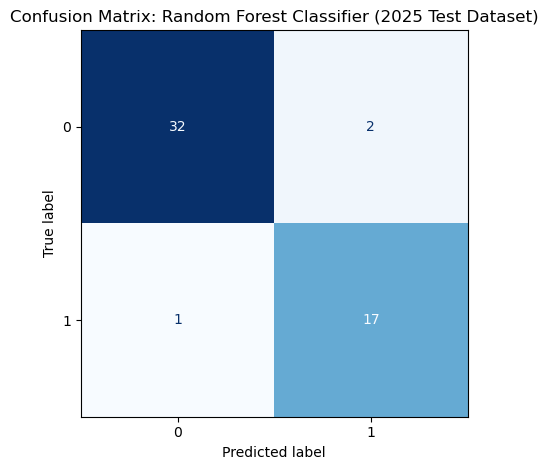

In [186]:
# CONFUSION MATRIX - RANDOM FOREST CLASSIFIER

from sklearn.metrics import ConfusionMatrixDisplay

best_classifier = rf_classifier_final

y_pred_rf = best_classifier.predict(X_test_cls)

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    y_pred_rf,
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Confusion Matrix: Random Forest Classifier (2025 Test Dataset)"
)

plt.tight_layout()
plt.show()

## Classification Performance Improvement Table

In [182]:
# CLASSIFICATION IMPROVEMENT AFTER BAYESIAN OPTIMIZATION

baseline = baseline_classification_results_df.copy()
optimized = final_classification_results_df.copy()

comparison = baseline.merge(
    optimized,
    on="Model",
    suffixes=("_Baseline", "_Optimized")
)

comparison["Accuracy Improvement (%)"] = (
    (comparison["Accuracy_Optimized"] -
     comparison["Accuracy_Baseline"])
    *100
)

comparison["F1-score Improvement (%)"] = (
    (comparison["F1-score_Optimized"] -
     comparison["F1-score_Baseline"])
    *100
)

comparison["ROC-AUC Improvement (%)"] = (
    (comparison["ROC-AUC_Optimized"] -
     comparison["ROC-AUC_Baseline"])
    *100
)

comparison = comparison[[
    "Model",
    "Accuracy_Baseline",
    "Accuracy_Optimized",
    "F1-score_Baseline",
    "F1-score_Optimized",
    "ROC-AUC_Baseline",
    "ROC-AUC_Optimized",
    "Accuracy Improvement (%)",
    "F1-score Improvement (%)",
    "ROC-AUC Improvement (%)"
]]

comparison = comparison.round(4)

display(comparison)

,Model,Accuracy_Baseline,Accuracy_Optimized,F1-score_Baseline,F1-score_Optimized,ROC-AUC_Baseline,ROC-AUC_Optimized,Accuracy Improvement (%),F1-score Improvement (%),ROC-AUC Improvement (%)
0,XGBoost Classifier,0.9231,0.9423,0.8889,0.9143,0.9815,0.9673,1.92,2.54,-1.42
1,Random Forest Classifier,0.8846,0.9423,0.8333,0.9143,0.9672,0.9493,5.77,8.10,-1.79
2,Logistic Regression,0.8654,0.8654,0.8205,0.8108,0.9580,0.9542,0.00,-0.97,-0.38
3,Support Vector Machine,0.8654,0.8269,0.8205,0.7805,0.8992,0.9297,-3.85,-4.00,3.05


## ROC Curve for All Optimized Classification Models

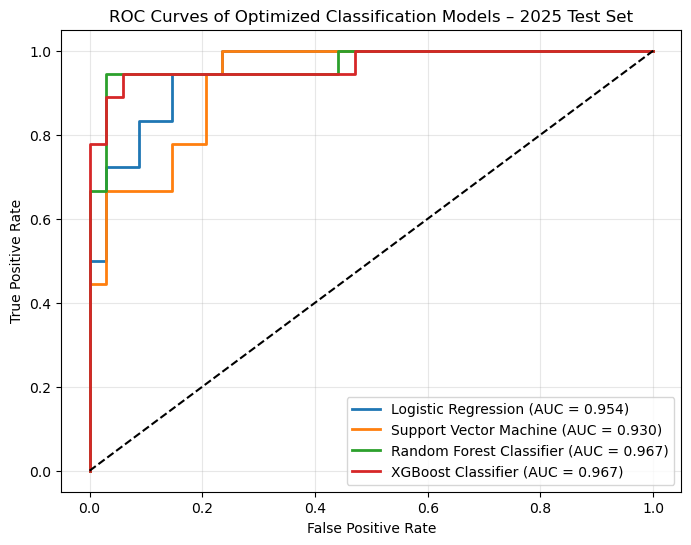

In [183]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(8, 6))

for name, model in final_classification_models.items():

    y_prob = model.predict_proba(X_test_cls)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test_cls,
        y_prob
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Optimized Classification Models – 2025 Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## WEEKLY PREDICTION RESULTS OF OPTIMIZED SVR

In [184]:
# WEEKLY PREDICTION RESULTS OF OPTIMIZED SVR

svr_weekly_predictions = pd.DataFrame({
    "Epi Week": test_df["epi_week"].values,
    "Actual Confirmed Cases": y_test_reg.values,
    "Predicted Confirmed Cases": final_regression_predictions[
        "Support Vector Regressor"
    ],
})

# Calculate prediction error
svr_weekly_predictions["Absolute Error"] = abs(
    svr_weekly_predictions["Actual Confirmed Cases"]
    - svr_weekly_predictions["Predicted Confirmed Cases"]
)

# Round predicted values and error
svr_weekly_predictions["Predicted Confirmed Cases"] = (
    svr_weekly_predictions["Predicted Confirmed Cases"].round(2)
)

svr_weekly_predictions["Absolute Error"] = (
    svr_weekly_predictions["Absolute Error"].round(2)
)

# Display all 52 weeks
svr_weekly_predictions

,Epi Week,Actual Confirmed Cases,Predicted Confirmed Cases,Absolute Error
0,1,54,64.57,10.57
1,2,89,67.40,21.60
2,3,71,78.06,7.06
3,4,76,81.00,5.00
4,5,68,75.66,7.66
5,6,54,70.30,16.30
6,7,38,59.72,21.72
7,8,54,54.09,0.09
8,9,29,49.96,20.96
9,10,28,43.00,15.00


## 2025 WEEK-BY-WEEK OUTBREAK STATUS PREDICTIONS

In [142]:
# 2025 WEEK-BY-WEEK OUTBREAK STATUS PREDICTIONS
# OPTIMIZED RANDOM FOREST CLASSIFIER

# Select the final optimized Random Forest model
rf_final = final_classification_models["Random Forest Classifier"]

# Generate predicted outbreak status
rf_pred = rf_final.predict(X_test_cls)

# Generate predicted outbreak probability
rf_prob = rf_final.predict_proba(X_test_cls)[:, 1]

# Create prediction table
rf_outbreak_predictions = pd.DataFrame({
    "Epi Week": test_df["epi_week"].values,
    "Actual Outbreak Status": y_test_cls.values,
    "Predicted Outbreak Status": rf_pred,
    "Predicted Outbreak Probability": rf_prob
})

# Convert probability to percentage
rf_outbreak_predictions["Outbreak Probability (%)"] = (
    rf_outbreak_predictions["Predicted Outbreak Probability"] * 100
).round(2)

# Convert numeric status to readable labels
rf_outbreak_predictions["Actual Status"] = (
    rf_outbreak_predictions["Actual Outbreak Status"]
    .map({0: "Non-outbreak", 1: "Outbreak"})
)

rf_outbreak_predictions["Predicted Status"] = (
    rf_outbreak_predictions["Predicted Outbreak Status"]
    .map({0: "Non-outbreak", 1: "Outbreak"})
)

# Final readable output
rf_outbreak_table = rf_outbreak_predictions[[
    "Epi Week",
    "Actual Status",
    "Predicted Status",
    "Outbreak Probability (%)"
]]

rf_outbreak_table

,Epi Week,Actual Status,Predicted Status,Outbreak Probability (%)
0,1,Outbreak,Outbreak,96.62
1,2,Outbreak,Outbreak,99.61
2,3,Outbreak,Outbreak,99.86
3,4,Outbreak,Outbreak,100.00
4,5,Outbreak,Outbreak,100.00
5,6,Outbreak,Outbreak,99.96
6,7,Outbreak,Outbreak,99.44
7,8,Outbreak,Outbreak,99.77
8,9,Outbreak,Outbreak,99.79
9,10,Outbreak,Outbreak,98.90


In [185]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_test_cls, rf_pred))

print("\nAccuracy:", accuracy_score(y_test_cls, rf_pred))
print("Precision:", precision_score(y_test_cls, rf_pred))
print("Recall:", recall_score(y_test_cls, rf_pred))
print("F1-score:", f1_score(y_test_cls, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test_cls, rf_prob))

Confusion Matrix:
[[33  1]
 [ 2 16]]

Accuracy: 0.9423076923076923
Precision: 0.9411764705882353
Recall: 0.8888888888888888
F1-score: 0.9142857142857143
ROC-AUC: 0.9493464052287582
